# Overcoming Modality Bias: An Iterative Approach to Active Speaker Detection

In [23]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np

# Video Downloading
import os
import urllib.request
import subprocess
from tqdm.auto import tqdm

# Preprocessing
import cv2
import torch
import librosa
from torchvision import transforms
from PIL import Image
from facenet_pytorch import InceptionResnetV1

# Training
import torch.nn as nn

# MlFlow graphs
import mlflow
from mlflow.tracking import MlflowClient

# Data sample comparisons
from torch.nn.functional import cosine_similarity
import glob

# --- Configuration & Constants ---
OFFSET_SEC = 900.0  # AVA starts at 15m
WINDOW_SIZE = 15    # 0.5s temporal context
SAMPLE_RATE = 16000 # Standard speech SR

# Download Videos
CSV_DIR = "./Ava_ActiveSpeaker_Dataset_sample/"
OUTPUT_DIR = "./Video_Sample"
TEMP_DIR = "./Video_Temp"

AVA_SAMPLE_PATH = "Ava_ActiveSpeaker_Dataset_sample/9Y_l9NsnYE0-activespeaker.csv"
PREPROCESSED_FILE_PATH = "Processed_Video_Sample/9Y_l9NsnYE0#9Y_l9NsnYE0@0900_0960_1#900.20.pt"

# Obviously change these if you want to run the preprocessing pipeline. I am using WSL on top of Windows
TRAIN_OUT = "/mnt/d/Programming/Softuni/Artificial Intelligence 2025/Deep Learning/softuni-dl-2025/Project/Processed_Video_Sample/"

DATASETS = [
    {
        "name": "TRAIN",
        "video_dir": "./Video_Sample",
        "csv_dir": "./Ava_ActiveSpeaker_Dataset_sample/",
        "out_dir": TRAIN_OUT
    }
    # You can add the test set as well here
]

## Section 1. Introduction & Objectives

### 1.1 The Inspiration: Intelligent Auto-Framing
Out of all the modalities that neural networks allow us to work with, I find Computer Vision the most compelling. To develop my skills in this area, I believe in "learning by doing," so I chose a project with a clear, practical application.

The idea came from the "Intelligent Camera" feature in tools like **Microsoft Teams** and **Zoom**, which automatically crops the video to focus on the active speaker. My goal was to dip my toes into the Computer Vision world and build a working solution that got as close as possible to this functionality.

I took a top-down approach: I started with the end goal and worked backward to find the immediate technical hurdles.
1. To zoom in, I first need to know *who* is speaking.
2. To know who is speaking, I need a model that correlates lips with sound.
3. To train that model, I need a high-quality dataset.
This journey led me into the field of **Active Speaker Detection (ASD)**.

### 1.2 Defining the Problem: Real-World ASD Challenges
Active Speaker Detection is a multimodal task requiring the analysis of a video stream and a shared audio track to identify which face is producing the speech. While it sounds simple, the implementation reveals several non-obvious failure points:

* **Modality Bias:** Neural networks are "lazy" - audio is a much easier signal to process than subtle 3D lip movement. In a meeting room with multiple people, the audio is "global." A naive model often fails to cross-reference the visual context; it hears sound and assumes every face on screen is talking because the audio signal is present for everyone.
* **The Majority-Silence Imbalance:** In natural conversation, participants spend significantly more time listening than speaking. If a model is trained on raw video, it quickly learns that it can achieve high accuracy by simply predicting "Silent" for everyone, all the time. Overcoming this statistical bias is crucial for a responsive system.
* **Temporal Coherence:** In a real-world application, the software needs to be stable. If a model only looks at a single moment in time, a sudden loud noise (like a pen dropping) might cause the camera to "flicker" - momentarily jumping to a silent person just because of a temporary spike in audio energy.
* **Speech Patterns over Time:** Human speech has a specific cadence; lips move in sync with syllables over a duration. By analyzing a **0.5-second window (15 frames)** rather than a static snapshot, the model can verify if the visual motion actually matches the audio pattern.

### 1.3 Project Scope & Resource Constraints
The ultimate goal of this project was to document the journey of building an ASD engine. However, I had to work within the constraints of my local hardware: an **Nvidia RTX 2060 Super (8GB VRAM)** and an **AMD Ryzen 5 3600**. 

These resources made "online" preprocessing (extracting features during training) unfeasible. Decoding high-resolution video files repeatedly on every epoch would have created a massive **CPU bottleneck**, leaving the GPU idle while waiting for the processor to provide the next batch of frames. This forced a strategic pivot to an **offline preprocessing pipeline**. By pre-calculating and saving features as tensors, I eliminated the repetitive decoding overhead, allowing the GPU to focus entirely on model optimization and enabling faster iteration.

**Note on Scope:** While the original intent included the final "auto-zoom" camera logic, the complexities of data engineering, training the neural network, and developing the visualization tools for the `live_demo.py` became the core focus. Consequently, this project focuses on developing and documenting the deep learning engine - the "brain" that identifies the speaker - which is the most critical precursor to any zooming functionality.

## Section 2. Data Acquisition Strategy

### 2.1 The AVA-ActiveSpeaker Dataset
To build a professional-grade ASD engine, I chose the **AVA-ActiveSpeaker** dataset. Released by Google Research, it is the first large-scale video dataset to provide highly accurate, frame-level annotations for active speaker detection in uncontrolled environments.

Unlike earlier datasets filmed in sterile lab environments, AVA consists of diverse movie clips and YouTube videos. This introduces significant real-world challenges:
* **Multiple Subjects:** Often 3 to 5 people are on screen simultaneously, while the audio track remains a single, global stream.
* **Occlusions & Lighting:** Faces are frequently partially covered, turned away, or in low-light conditions.
* **Temporal Structure:** Each video in the dataset is actually a **15-minute segment** extracted from a full-length movie, specifically starting from the **15th minute (900 seconds)** mark. This is why an offset of 900 seconds is mandatory during preprocessing to align CSV timestamps with the local video files.

#### Training and Test Splits
Google provides the dataset in pre-defined segments. Upon unzipping the official archives, the distribution consists strictly of annotation files:
* **Train Set:** 120 CSV files.
* **Test Set:** 33 CSV files.

#### Inside the Annotation Files
Each CSV file follows a naming convention of `[VideoID]-activespeaker.csv`. The data follows a strict column format that requires parsing to associate timestamps with specific individuals (entities).

**CSV Column Structure:**
1. **video_id**: The YouTube identifier.
2. **frame_timestamp**: The time in seconds.
3. **x1, y1, x2, y2**: Normalized bounding box coordinates.
4. **label**: `SPEAKING_AND_AUDIBLE`, `SPEAKING_BUT_INAUDIBLE`, or `NOT_SPEAKING`.
5. **entity_id**: A unique structured identifier for each person. For example, in `9Y_l9NsnYE0_1680_1740:6`:
    * `9Y_l9NsnYE0` is the Video ID.
    * `1680_1740` is the specific 60-second segment from the original film.
    * `:6` is the unique index assigned to that specific individual within that segment.

**The Purpose of the entity_id:**
In a scene with multiple people, the `entity_id` is our only way to distinguish who is who. In the Preprocessing section, I will detail how we use this ID to solve **Multi-Speaker Ambiguity** -isolating distinct training samples for every individual in a frame (as multiple csv rows can be pointing to the same frame, some labeled as not speaking, one labeled as speaking).
   
**Understanding Normalized Coordinates:**
An important detail for the preprocessing script is that the bounding box values (`x1`, `y1`, `x2`, `y2`) are not provided in pixels. Instead, they are **normalized percentages** of the screen's total width and height (ranging from 0.0 to 1.0). 
* `x1, x2` must be multiplied by the image **width**.
* `y1, y2` must be multiplied by the image **height**.

#### Label Statistics (Table 1 from Official Paper)
The following data highlights the distribution of labels across the dataset. The target class (S&A) represents only about 25% of the total time, while the majority of the data is background noise or silence (NS).

| Label | Description | Total Time | # Segments | Mean Duration |
| :--- | :--- | :--- | :--- | :--- |
| **NS** | Not Speaking | 28.10 hours | 58,171 | 1.74 seconds |
| **S&A** | Speaking & Audible (Target) | 9.46 hours | 30,623 | 1.11 seconds |
| **S&NA** | Speaking & Not Audible | 0.35 hours | 1,547 | 0.83 seconds |

**Official Resources & References:**
* **Official Website:** [Google Research - AVA](https://research.google.com/ava/)
* **Primary Source:** Chung, J. S., et al. (2019). "AVA-ActiveSpeaker: An Audio-Visual Dataset for Active Speaker Detection." *ArXiv*. [https://arxiv.org/abs/1901.01342](https://arxiv.org/abs/1901.01342)

**Real Example (9Y_l9NsnYE0 sample file):**

In [23]:
cols = [
    'video_id', 
    'frame_timestamp', 
    'x1', 'y1', 'x2', 'y2', 
    'label', 
    'entity_id'
]

df = pd.read_csv(AVA_SAMPLE_PATH, header=None, names=cols)
from IPython.display import display, HTML

# Technical inspection
print("--- Data Sample ---")
display(HTML(df.head().to_html()))

print("\n--- Class Distribution ---")
print(df['label'].value_counts())

--- Data Sample ---


,video_id,frame_timestamp,x1,y1,x2,y2,label,entity_id
0,9Y_l9NsnYE0,1682.95,0.49375,0.122917,0.787500,0.577083,NOT_SPEAKING,9Y_l9NsnYE0_1680_1740:6
1,9Y_l9NsnYE0,1683.00,0.49375,0.125000,0.787500,0.577083,NOT_SPEAKING,9Y_l9NsnYE0_1680_1740:6
2,9Y_l9NsnYE0,1683.04,0.49375,0.125000,0.787500,0.577083,NOT_SPEAKING,9Y_l9NsnYE0_1680_1740:6
3,9Y_l9NsnYE0,1683.07,0.49375,0.125000,0.785937,0.577083,NOT_SPEAKING,9Y_l9NsnYE0_1680_1740:6
4,9Y_l9NsnYE0,1683.11,0.49375,0.125000,0.784375,0.577083,NOT_SPEAKING,9Y_l9NsnYE0_1680_1740:6



--- Class Distribution ---
label
NOT_SPEAKING            34250
SPEAKING_AUDIBLE        10487
SPEAKING_NOT_AUDIBLE      214
Name: count, dtype: int64


### 2.2 Downloading the Videos
The first major hurdle in the "Top-Down" approach was simply acquiring the raw video files. While Google provides the CSV annotations, they do not host the video files directly. Researchers are expected to source themselves.

#### The YouTube Failure
Since we have a YouTube VideoId I initially attempted to download the files via YouTube. However, due to the age of the dataset, "link rot" was a massive issue. Out of the 120 training videos, **only 47 were still available**. The remaining 73 videos had been deleted or made private (some were age/country restricted), rendering the official acquisition method obsolete for a complete training run.

#### The Amazon S3 Pivot
Following documentation found on the [CVDFoundation/AVA-Dataset GitHub](https://github.com/cvdfoundation/ava-dataset), I moved to using official **Amazon S3 mirrors**. These buckets host the full-length movies from which the AVA clips were originally sourced.

To manage this, I developed the following pipeline:
1. **Probing:** Checking S3 for `.mkv`, `.mp4`, or `.webm` versions of each Video ID.
2. **Temp Storage:** Downloading the full-length movie (often several GBs) to a temporary folder.
3. **FFmpeg Slicing:** Using `ffmpeg -ss 900 -t 900` to extract the specific 15-minute segment required by the dataset. 
4. **Re-encoding for Accuracy:** I utilized `-c:v libx264` during the cut. Re-encoding was necessary to ensure frame-accurate synchronization; simply copying the stream often leads to "seeking" errors where the video and CSV timestamps fall out of alignment.
5. **Disk Management:** Automatically deleting the large source files after extraction to maintain storage efficiency.

By automating this acquisition through the S3 mirrors, I successfully recovered the missing segments, moving from 47 available videos to the full 120-video training set.

*There were 3 videos in `.webm` format that I had issues with so I just deleted them. Hence 117 videos from now on, not 120

*There are some movies in the dataset that are dubbed, hence lip movement is not matched to the words, but what can you do ...

In [44]:
class TqdmUpTo(tqdm):
    """Provides progress bar updates for urllib.request.urlretrieve."""
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

def download_and_slice_ava_videos(csv_dir, output_dir, temp_dir, target_id=None):
    """
    Scans for missing AVA videos and processes them. 
    If target_id is provided, only that specific video is processed.
    
    Args:
        csv_dir (str): Path to the directory containing AVA label CSVs.
        output_dir (str): Final storage path for 15-minute segments.
        temp_dir (str): Staging area for full-length movie downloads.
        target_id (str, optional): A specific Video ID to process. 
                                   Defaults to None (processes all missing).
    """
    if not os.path.exists(csv_dir):
        print(f"Error: CSV Directory '{csv_dir}' not found.")
        return

    # Determine which IDs to process
    if target_id:
        print(f"Single target mode: Focus on {target_id}")
        ids_to_process = [target_id]
    else:
        # Default behavior: Find all missing videos
        video_ids = [f.replace("-activespeaker.csv", "") for f in os.listdir(csv_dir) 
                     if f.endswith("-activespeaker.csv")]
        existing = {os.path.splitext(f)[0] for f in os.listdir(output_dir)}
        ids_to_process = [vid for vid in video_ids if vid not in existing]
        print(f"Batch mode: {len(ids_to_process)} missing videos identified.")

    extensions = [".mkv", ".mp4", ".webm"]

    for vid_id in ids_to_process:
        success = False
        for ext in extensions:
            file_name = f"{vid_id}{ext}"
            url = f"https://s3.amazonaws.com/ava-dataset/trainval/{file_name}"
            temp_path = os.path.join(temp_dir, file_name)
            final_path = os.path.join(output_dir, f"{vid_id}.mp4")

            try:
                # 1. Check if file exists on S3
                req = urllib.request.Request(url, method="HEAD")
                urllib.request.urlopen(req)

                # 2. Download with Progress Bar
                with TqdmUpTo(unit='B', unit_scale=True, unit_divisor=1024, miniters=1, desc=f"Downloading {file_name}") as t:
                    urllib.request.urlretrieve(url, filename=temp_path, reporthook=t.update_to)

                # 3. FFmpeg Slicing & Re-encoding (15m start, 15m duration)
                print(f"Slicing {file_name} for perfect sync...")
                cmd = [
                    "ffmpeg", "-hide_banner", "-loglevel", "error", "-y",
                    "-ss", "900", "-i", temp_path, "-t", "900",
                    "-c:v", "libx264", "-preset", "veryfast", "-crf", "22",
                    "-c:a", "aac", final_path
                ]
                subprocess.run(cmd, check=True)

                # 4. Cleanup
                if os.path.exists(temp_path):
                    os.remove(temp_path)
                
                success = True
                break 
                
            except urllib.error.HTTPError as e:
                if e.code == 404: continue 
            except Exception as e:
                print(f"\n[ERROR] Pipeline failed for {vid_id}: {e}")
                if os.path.exists(temp_path): os.remove(temp_path)
                continue

        if not success:
            print(f"\n[WARNING] Could not process '{vid_id}'.")

    print("Process finished.")

In [46]:
download_and_slice_ava_videos(CSV_DIR, OUTPUT_DIR, TEMP_DIR)

Batch mode: 1 missing videos identified.


Slicing 9Y_l9NsnYE0.mp4 for perfect sync...
Process finished.


## Section 3. Preprocessing & Feature Extraction

With the raw videos and CSV annotations secured, the next challenge was transforming **14 GB (for the train) of unstructured media** into a compressed, multimodal format. This phase was the most computationally expensive part of the project. In the end I was left with **21.4 GB** of preprocessed .pt files.

### 3.1 Pipeline Optimization: Solving the Decoding Bottleneck
My initial attempts at frame extraction resulted in processing times of **over 7 hours for just 10 videos**.

#### The Failure of Random Access
My initial script relied on 
```
cap = cv2.VideoCapture(video_path)
cap.set(...)
```
to jump to specific timestamps. I quickly realized that modern video compression (like H.264) uses [**Inter-frame compression (IPB Frames)**](https://www.fastpix.io/blog/understanding-video-inter-frame-compression), meaning not every frame is a full image. To "jump" to a specific frame, OpenCV must find the nearest preceding **I-Frame (Keyframe)** and sequentially decode every intermediate **P/B-Frame** to reconstruct the target image. 

<img src="Images/IFC.jpeg" width=800>


By jumping around for every person and every window, I was forcing the CPU into a redundant "seek-and-decode" loop, re-processing the same chunks of video thousands of times. This mistake resulted in a processing time of **over 7 hours for just 10 videos** - a pace that would have made finishing the project impossible.

#### The Optimization: Sequential [grab/retrieve](https://stackoverflow.com/a/57717037)
To achieve the final efficiency (~31 hours for 117 videos), I pivoted to a **Conditional Decoding** strategy using a sequential `grab/retrieve` architecture. Instead of jumping, the script reads the video linearly from frame zero:

1.  **cap.grab():** This is a lightweight operation that simply advances the file pointer in the bitstream. It is extremely fast because it bypasses the actual pixel decompression.
2.  **Metadata Mapping:** I implemented a hash map of all required frame indices derived from the CSV.
3.  **cap.retrieve():** Only when the current frame index exists in the map does the script execute `cap.retrieve()`, which performs the heavy lifting of decoding the compressed bytes into a raw BGR image for GPU inference.

By "grabbing" everything but only "retrieving" the exact frames needed for the **VGGFace2 (InceptionResnetV1)** model, I eliminated the repetitive decoding overhead entirely.

In [53]:
def process_video_sequential(video_id, video_dir, csv_dir, out_dir, resnet, v_transform, pbar=None):
    """
    Core Pipeline: Maps frames, decodes sequentially, and saves multimodal tensors.

    Args:
        video_id (str): The unique YouTube identifier for the source video.
        video_dir (str): Path to the directory containing raw .mp4 or .mkv files.
        csv_dir (str): Path to the directory containing AVA-ActiveSpeaker label CSVs.
        out_dir (str): The absolute path where processed .pt tensors will be saved.
        resnet (nn.Module): The pretrained InceptionResnetV1 model used for 
                            extracting 512-dim visual embeddings.
        v_transform (transforms.Compose): The torchvision preprocessing chain (resize, normalize) for face crops.
        pbar (tqdm, optional): A tqdm progress bar instance used to update status strings during the 3-step execution.
    
    Returns:
        bool: True if the video was processed or skipped (exists), 
              False if critical files (Video/CSV) were missing.
    """
    # 1. Resource Validation & Loading
    video_path = os.path.join(video_dir, f"{video_id}.mp4")
    csv_path = os.path.join(csv_dir, f"{video_id}-activespeaker.csv")
    if not os.path.exists(csv_path) or not os.path.exists(video_path): return False

    try:
        full_audio, _ = librosa.load(video_path, sr=SAMPLE_RATE)
        df = pd.read_csv(csv_path, header=None, names=['id', 'ts', 'x1', 'y1', 'x2', 'y2', 'label', 'entity'])
        df = df.sort_values(by=['entity', 'ts'])
    except: return False

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 29.97

    # STEP 1/3: PRE-MAPPING
    # Group by entity to identify "Temporal Tubes" and required frame indices
    required_frames = {}
    windows_to_process = []
    unique_entities = df['entity'].unique()
    
    for entity_id in unique_entities:
        group = df[df['entity'] == entity_id].sort_values('ts')
        metadata = str(entity_id)[len(video_id)+1:].replace(":", "_")
        
        for i in range(0, len(group) - WINDOW_SIZE, 5): # Stride of 5 frames
            window = group.iloc[i : i + WINDOW_SIZE]
            if (window['ts'].max() - window['ts'].min()) > 0.6: continue
            
            fn = f"{video_id}#{video_id}@{metadata}#{window.iloc[0]['ts']:.2f}.pt"
            final_path = os.path.join(out_dir, fn)
            if os.path.exists(final_path): continue
                
            windows_to_process.append((entity_id, window, final_path))
            for _, row in window.iterrows():
                f_idx = int((row['ts'] - OFFSET_SEC) * fps)
                required_frames.setdefault(f_idx, []).append({
                    'ent': entity_id, 
                    'box': (row['x1'], row['y1'], row['x2'], row['y2'])
                })

    if not windows_to_process: return True

    # STEP 2/3: SEQUENTIAL DECODING & BACKBONE INFERENCE
    # Uses grab/retrieve to advance linearly through the video stream
    max_frame = max(required_frames.keys())
    extracted_features = {ent: {} for ent in unique_entities}
    current_frame = 0

    while current_frame <= max_frame:
        success = cap.grab()
        if not success: break

        if current_frame in required_frames:
            ret, frame = cap.retrieve()
            if ret:
                h, w, _ = frame.shape
                batch_t, batch_e = [], []
                for req in required_frames[current_frame]:
                    x1, y1, x2, y2 = req['box']
                    face = frame[max(0, int(y1*h)):min(h, int(y2*h)), 
                                 max(0, int(x1*w)):min(w, int(x2*w))]
                    if face.size > 0:
                        face_pil = Image.fromarray(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
                        batch_t.append(v_transform(face_pil))
                        batch_e.append(req['ent'])
                
                if batch_t:
                    input_b = torch.stack(batch_t).to('cuda')
                    with torch.no_grad():
                        feats = resnet(input_b).cpu()
                    for j, ent in enumerate(batch_e):
                        extracted_features[ent][current_frame] = feats[j]
        current_frame += 1
    cap.release()

    # STEP 3/3: MULTIMODAL FUSION & SERIALIZATION
    # Pairs visual embeddings with normalized audio Mel-spectrograms
    for ent, window, f_path in windows_to_process:
        v_feats, raw_mels, valid = [], [], True
        for _, row in window.iterrows():
            f_idx = int((row['ts'] - OFFSET_SEC) * fps)
            feat = extracted_features[ent].get(f_idx)
            ts = row['ts'] - OFFSET_SEC
            s_s, e_s = int((ts-0.016)*SAMPLE_RATE), int((ts+0.016)*SAMPLE_RATE)
            
            if feat is None or s_s < 0 or e_s > len(full_audio):
                valid = False; break
            
            v_feats.append(feat)
            clip = full_audio[s_s:e_s]
            if len(clip) < 512: clip = np.pad(clip, (0, 512-len(clip)))
            mel = librosa.feature.melspectrogram(y=clip, sr=SAMPLE_RATE, n_mels=64, hop_length=128, n_fft=512)
            raw_mels.append(mel[:, :5])

        if valid and len(v_feats) == WINDOW_SIZE:
            # Window-based Audio Normalization
            w_max = max(np.max(m) for m in raw_mels) if any(np.max(m)>0 for m in raw_mels) else 1.0
            a_tensors = [torch.tensor((librosa.power_to_db(m, ref=w_max)+40)/40).unsqueeze(0) for m in raw_mels]
            label = 1 if "SPEAKING_AUDIBLE" in window.iloc[WINDOW_SIZE//2]['label'] else 0
            
            torch.save({'visual': torch.stack(v_feats), 'audio': torch.stack(a_tensors), 'label': label}, f_path)
    return True

In [54]:
def run_preprocessing_factory(limit=117):
    """
    Orchestrates the batch processing of Training and Testing datasets.
    
    Args:
        limit (int): Max number of new videos to process per run to 
                     manage disk space and time.
    """
    # 1. Initialize InceptionResnetV1 with VGGFace2 weights
    print("Initializing Visual Backbone: InceptionResnetV1 (vggface2)...")
    resnet = InceptionResnetV1(pretrained='vggface2').eval().to('cuda')

    # 2. Define standard spatial transformations
    v_transform = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    # 3. Iterate through Dataset splits (Train/Test)
    for ds in DATASETS:
        print(f"\n--- Starting Split: {ds['name']} ---")
        os.makedirs(ds["out_dir"], exist_ok=True)
        
        # Identify available video files
        available = [f.split('.')[0] for f in os.listdir(ds["video_dir"]) 
                     if f.lower().endswith((".mp4", ".mkv"))]
        
        # Apply the processing limit
        todo = available[:limit]
        pbar = tqdm(todo, desc=f"Processing {ds['name']}")
        
        for vid in pbar:
            # Update TQDM status bar with current Video ID
            pbar.set_description(f"Processing: {vid}")
            
            # Execute the sequential pipeline
            success = process_video_sequential(
                video_id=vid, 
                video_dir=ds["video_dir"], 
                csv_dir=ds["csv_dir"], 
                out_dir=ds["out_dir"], 
                resnet=resnet, 
                v_transform=v_transform, 
                pbar=pbar
            )
            
            if not success:
                print(f" [!] Warning: Failed to process {vid}")

    # Ensure all file handles are closed and disk buffers are flushed
    if hasattr(os, 'sync'):
        os.sync()
    print("\n[SUCCESS] Preprocessing Factory run complete.")


run_preprocessing_factory(limit=1)

Initializing Visual Backbone: InceptionResnetV1 (vggface2)...

--- Starting Split: TRAIN ---


/tmp/ipykernel_21331/406348071.py:25: UserWarning: PySoundFile failed. Trying audioread instead.  | 0/1 [00:00<?, ?it/s]
  full_audio, _ = librosa.load(video_path, sr=SAMPLE_RATE)
/home/alpine/miniconda3/envs/dl/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Processing: 9Y_l9NsnYE0: 100%|███████████████████████████████████████████████████████████| 1/1 [16:03<00:00, 963.15s/it]


[SUCCESS] Preprocessing Factory run complete.


### 3.2 Visual Feature Engineering (step 2 in the code)

Rather than feeding raw video pixels into our downstream Transformer model - which would be highly inefficient and prone to overfitting-we use a "Frozen Backbone" approach to extract high-level semantic features representing the face.

* **Backbone Initialization:** In the `run_preprocessing_factory`, we instantiate an **InceptionResnetV1** model pretrained on the **VGGFace2** dataset. Crucially, this model is instantiated *once* and passed into the sequential processor. This architectural choice prevents VRAM fragmentation and avoids the massive overhead of reloading weights for every video.
* **Spatial Processing (`v_transform`):** When a required frame is decoded, the face is cropped using the CSV's normalized bounding box coordinates and converted to RGB. It is then passed through a torchvision transform pipeline that resizes the crop to **160x160 pixels** and normalizes the color channels (mean and standard deviation of 0.5) to match the exact input distribution the VGGFace2 model expects.
* **GPU Batch Inference:** To fully saturate the RTX 2060 Super, the script implements dynamic batching. If there are 4 different people on screen in a single frame, their crops are stacked into a single tensor batch (`torch.stack(batch_t)`) and processed by the ResNet simultaneously. 
* **Embedding:** The output is a **512-dimensional feature vector** for each face. This effectively compresses the spatial geometry, lip position, and identity of the speaker into a lightweight mathematical representation. 
### 3.3 Audio Feature Engineering: Temporal Window Normalization (step 3 in the code)

Processing audio for an Active Speaker Detection system presents a unique challenge: the model must be robust enough to handle varying microphone gains and background noise levels across different environments without relying on the entire video's audio track (which wouldn't be available in a live stream).

* **Frame-Centric Extraction:** During the Fusion step (Step 3/3 in the code), the script maps the visual frame timestamp (`ts`) to the loaded `librosa` audio array. It isolates a tiny **32-millisecond audio clip** (±0.016 seconds) centered exactly on that frame. If the clip is too short, it is zero-padded to ensure uniform dimensions.
* **Mel-Spectrogram Generation:** The raw 1D waveform is converted into a 2D representation using `librosa.feature.melspectrogram` with `n_mels=64` and `n_fft=512`. We slice the first 5 temporal steps, resulting in a discrete `[64, 5]` matrix for each video frame. * **Stateless Temporal Normalization:** To mimic the conditions of a real-time live demo, I implemented **Local Scaling**. 
    1. The script groups 15 audio frames (representing a 0.5-second temporal window).
    2. It finds the absolute loudest peak (`w_max`) *within that specific window*.
    3. It converts the audio to decibels relative to this local peak using the formula: `(librosa.power_to_db(m, ref=w_max) + 40) / 40`.
    4. **The Math:** This formula assumes a 40dB dynamic range. Anything quieter than -40dB relative to the peak becomes 0.0 (silence), and the peak itself becomes 1.0. This scales the audio into a neural-network-friendly `[0, 1]` tensor format, rendering the features entirely relative to their immediate 0.5-second context.

### 3.4 Temporal Windowing & Serialization
The final step involved grouping multimodal features into sequences of **15 frames**. The data was serialized into `.pt` tensors using a structured naming convention: `VideoID#Metadata#Timestamp.pt`. 

#### Naming Convention & Data Splitting
I designed a specific naming convention for the `.pt` files to enforce strict dataset splitting without needing to open the files.

**Example Filename:** `WlgxRNCHQzw#WlgxRNCHQzw@1740_1800_8#1742.35.pt`

* **The `#` Delimiter:** This separates the base **Video ID** from the rest of the metadata. During dataloading, the script splits the string at the `#` to group files by their source movie. This ensures a strict Train/Validation split - preventing frames of the same scene from leaking across datasets and artificially inflating validation accuracy.
* **The `@` Delimiter:** Represents the **Entity Track ID** (e.g., Person 8). This was utilized during the preprocessing phase to guarantee that the 15 frames packed into this specific `.pt` file belong to the same continuous person, forming a pure temporal window.
* The `#` and `@` delimiters were choses as such because I ran into issues while using `_` or `-` where the VideoId from Yuotube actually ends on or starts with these symbols, which messed up the name parsing, so I had to chose names that Windows allows and are not in Youtube's VideoIds. Hence `#` and `@`

#### Internal Tensor Structure:
* **'visual'**: `[15, 512]` (VGGFace2 Embeddings).
* **'audio'**: `[15, 1, 64, 5]` (Normalized Mel-spectrograms).
* **'label'**: Binary (0 or 1) based on the center frame's annotation.

#### The Compute vs. Storage Tradeoff
While this serialization method actually *increased* the total footprint of the dataset on disk (as uncompressed float32 tensors require significantly more storage than H.264 compressed video), it was a necessary architectural tradeoff. 

By pre-computing the InceptionResnetV1 and Librosa outputs, we shifted the pipeline bottleneck from Compute to I/O. This allowed for lightning-fast data loading during the training phase. The dataloader can now stream these high-level embeddings directly into the Transformer's VRAM in milliseconds, completely bypassing the massive CPU/GPU overhead of decoding video frames and running a heavy CNN during the actual training loop.

#### Visualizing the preprocessed .pt file

Source: Processed_Video_Sample/9Y_l9NsnYE0#9Y_l9NsnYE0@0900_0960_1#900.20.pt
Status: Active Speaker


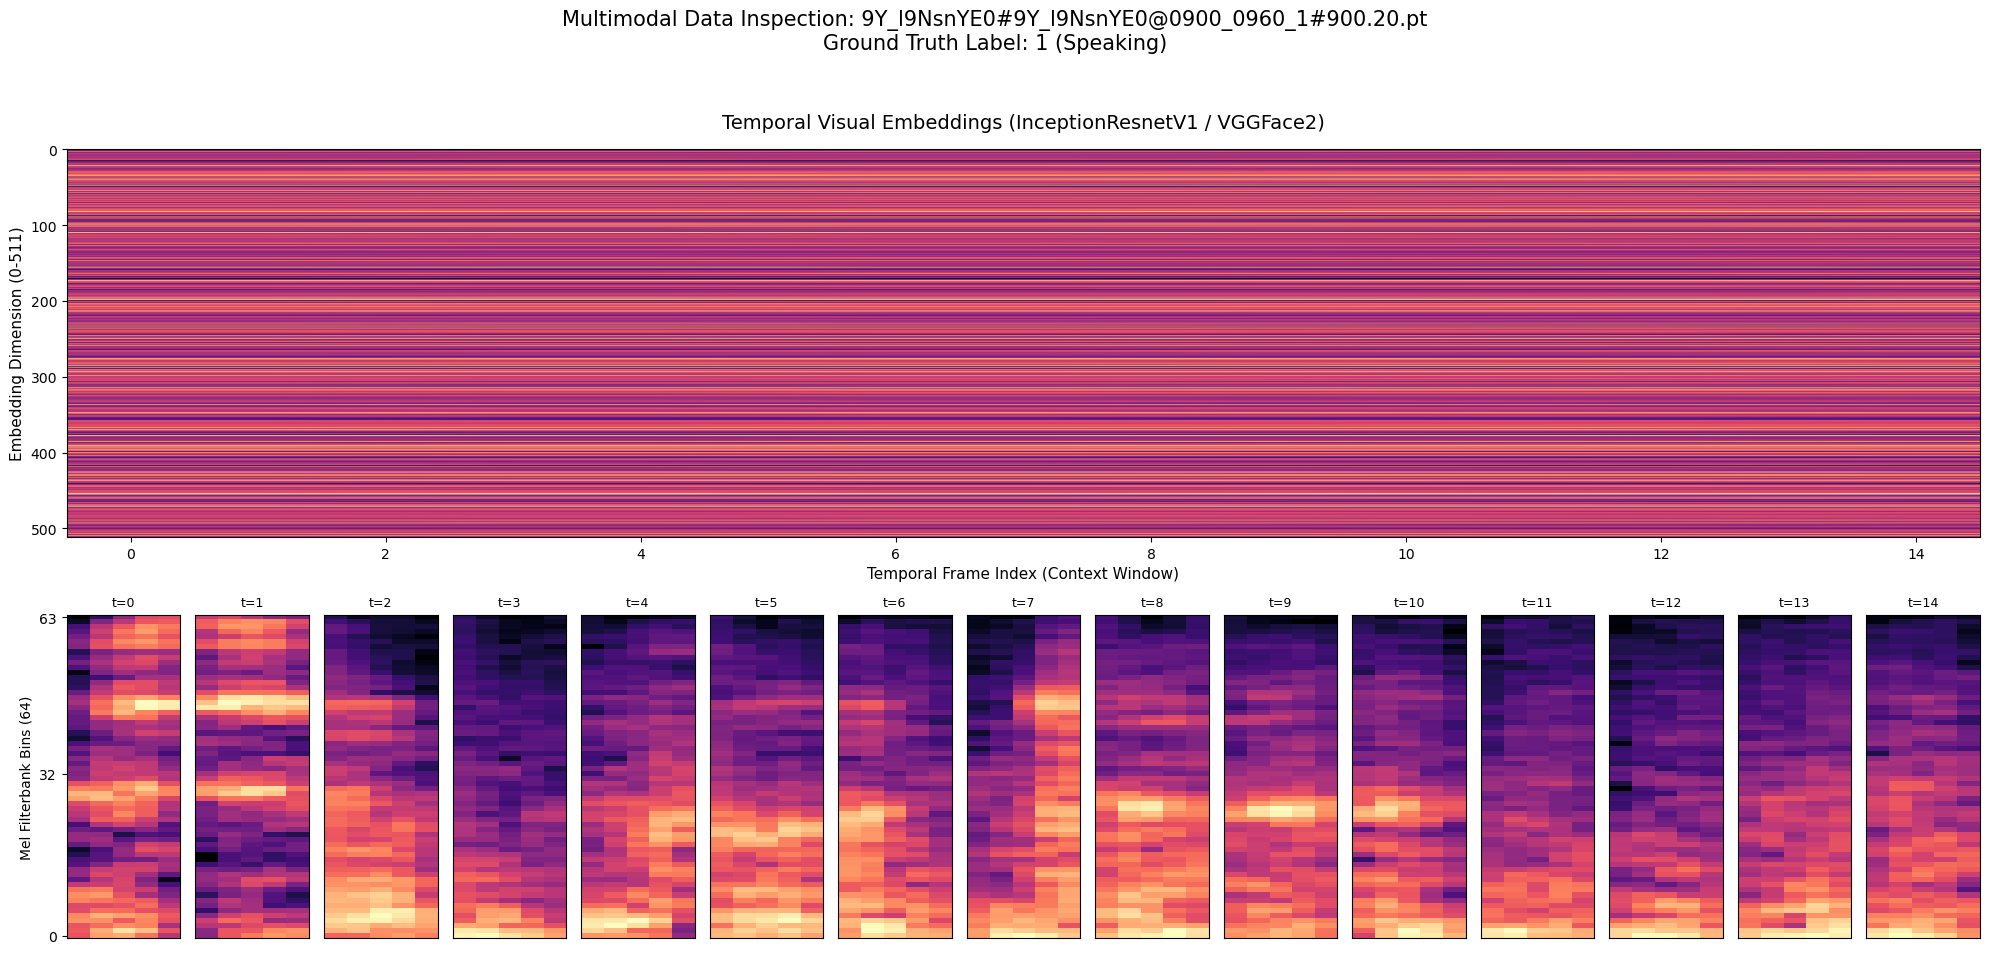

In [4]:
def inspect_multimodal_tensor(file_path):
    """
    Loads a processed .pt file and visualizes the high-level visual 
    embeddings and the associated temporal audio spectrograms with clear labeling.
    """
    try:
        # Expected structure: {'visual': [15, 512], 'audio': [15, 1, 64, 5], 'label': int}
        data = torch.load(file_path)
    except Exception as e:
        print(f"Failed to load tensor: {e}")
        return

    visual_feats = data['visual']
    audio_feats = data['audio']
    label = data['label']

    print(f"Source: {file_path}")
    print(f"Status: {'Active Speaker' if label == 1 else 'Inactive/Passive'}")

    fig = plt.figure(figsize=(20, 10))
    grid = fig.add_gridspec(2, 15, height_ratios=[1.2, 1])

    # 1. Visual Feature Map (VGGFace2 Embeddings)
    # The Y-axis represents the 512-dimensional embedding space
    ax_visual = fig.add_subplot(grid[0, :])
    im_v = ax_visual.imshow(visual_feats.numpy().T, aspect='auto', cmap='magma')
    ax_visual.set_title("Temporal Visual Embeddings (InceptionResnetV1 / VGGFace2)", fontsize=14, pad=15)
    ax_visual.set_ylabel("Embedding Dimension (0-511)", fontsize=11)
    ax_visual.set_xlabel("Temporal Frame Index (Context Window)", fontsize=11)

    # 2. Audio Temporal Window (Mel-Spectrograms)
    # The Y-axis of the first spectrogram represents the frequency bins
    for i in range(15):
        ax_audio = fig.add_subplot(grid[1, i])
        mel_slice = audio_feats[i].squeeze().numpy()
        
        # Display the spectrogram
        im_a = ax_audio.imshow(mel_slice, aspect='auto', origin='lower', cmap='magma')
        
        # Only show Y-axis label for the first plot in the row to keep it clean
        if i == 0:
            ax_audio.set_ylabel("Mel Filterbank Bins (64)", fontsize=10)
            ax_audio.set_yticks([0, 32, 63])
        else:
            ax_audio.set_yticks([])
            
        ax_audio.set_xticks([]) # Time steps (5) are too short for meaningful X-ticks
        ax_audio.set_title(f"t={i}", fontsize=9)

    plt.suptitle(f"Multimodal Data Inspection: {file_path.split('/')[-1]}\n"
                 f"Ground Truth Label: {label} ({'Speaking' if label == 1 else 'Silent'})", 
                 fontsize=15, y=0.98)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Example usage:
inspect_multimodal_tensor(PREPROCESSED_FILE_PATH)

> Hint: remember how the Visual embedding looks like. It is important for Section 6

## Section 4: Dataset Loading and Augmentation

>*Disclaimer: I will be posting snippets from the actual complete training code in the next sections. You can see the complete version and its execution in the **Train.ipynb** notebook.

To effectively train the Cross-Modal Temporal model, the pipeline must efficiently load the pre-extracted tensors while ensuring strict evaluation integrity and robust data augmentation.

### 4.1 The AVAVectorDataset and Hard Negative "Dubbing"

A common failure state for Active Speaker Detection models is becoming a "microphone picker." Because the dataset is heavily imbalanced toward silence, a naive model might learn to predict "Speaking" whenever it hears loud audio, ignoring whether the lips match the sound.

To force the model to learn true cross-modal synchronization, I made a custom `AVAVectorDataset` that builds an internal "Audio Pool" of active speaking tracks. During training, if a frame is labeled as silent, there is a probability that its audio will be replaced by a random active track from the pool.

This synthetic "dubbing" forces the model to realize that loud audio + silent lips = 0 (Silent).

This can be controlled during experimentation through the `hard_negative_prob = ...` hyperparameter

In [ ]:
class AVAVectorDataset(Dataset):
    def __init__(self, root_dir, file_list, hard_negative_prob=0.0, pool_size=500):
        self.root_dir = root_dir
        self.file_list = file_list
        self.hard_negative_prob = hard_negative_prob
        self.audio_pool = []

        # Build a pool of strictly active audio tracks
        if self.hard_negative_prob > 0.0:
            sample_list = file_list.copy()
            random.shuffle(sample_list)
            
            for f in sample_list:
                if len(self.audio_pool) >= pool_size:
                    break
                data = torch.load(os.path.join(self.root_dir, f), weights_only=True)
                if data['label'] == 1:
                    self.audio_pool.append(data['audio'])

    def __len__(self): 
        return len(self.file_list)

    def __getitem__(self, idx):
        path = os.path.join(self.root_dir, self.file_list[idx])
        data = torch.load(path, weights_only=True)
        v, a, l = data['visual'], data['audio'], data['label']

        # Hard Negative Dubbing Check
        if self.hard_negative_prob > 0.0 and l == 0:
            if random.random() < self.hard_negative_prob and self.audio_pool:
                # Replace silent audio with active audio from another video
                a = random.choice(self.audio_pool)

        return v, a, torch.tensor(l, dtype=torch.long)

### 4.2 Strict Train/Validation Splitting (Preventing Leakage)

It is always best to design your train/val split in such a way to avoid Data leakage. If sequential frames from the same video exist in both the training and validation sets, the model will memorize specific faces and background noise rather than learning the generalized task of lip-sync detection.

To guarantee isolation, the pipeline enforces a strict grouping split based on the video origin. Utilizing the `#` delimiter in the filename, the script identifies the source video id and strictly segregates all associated frames into either the 85% Train or 15% Validation sets.

#### 4.2.1 Why use an 85/15 split

I have 445,514 sample .pt files in the train set. Since they are quite a lot usually one would separate 20k maybe for the validation adn the rest 425k for the training. In this case, due to the heavy negative class bias and the proclivity to choose the easy way out by relying on the audio too much, I chose to leave more validation samples so that I can be sure that the validation really is ... well valid.

Additionally this gives less samples for training, which is nice, since I had a very limited time, and an epoch with 85/15% split was already taking 22min for the training and 3min for validation. If I increased the training set it would make it even worse. It saved some time.

Typically the sample distribution goes like this:
- TRAIN: 381,243 samples
- VAL:    64,271 samples

In [ ]:
VALIDATION_SET_PERCENTAGE = 0.15

# Extract unique Video IDs using the '#' delimiter
train_files_raw = [f for f in os.listdir(TRAIN_DIR) if f.endswith('.pt')]
train_val_video_ids = list(set([f.split('#')[0] for f in train_files_raw if '#' in f]))

# Shuffle and split by Video ID, NOT by individual frames
random.shuffle(train_val_video_ids)
num_val = max(1, int(len(train_val_video_ids) * VALIDATION_SET_PERCENTAGE)) # max is used to enshure if we test with a very small vidoe count like 5, atleast 1 would be for validation

val_vids = train_val_video_ids[:num_val]
train_vids = train_val_video_ids[num_val:]

# Re-associate files with their designated split
train_files = [f for f in train_files_raw if f.split('#')[0] in train_vids]
val_files = [f for f in train_files_raw if f.split('#')[0] in val_vids]

# Initialize the DataSet classes
train_ds = AVAVectorDataset(TRAIN_DIR, train_files, hard_negative_prob=HARD_NEG_PROB, pool_size=500)
val_ds = AVAVectorDataset(TRAIN_DIR, val_files, hard_negative_prob=0.0)
test_ds = AVAVectorDataset(TEST_DIR, test_files, hard_negative_prob=0.0)

# Initialize the DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)

## Section 5: Architectural Evolution and Cross-Modal Attention

### 5.1 The Progression of Models
The model architecture evolved through three distinct phases to address specific failure states encountered during development:

#### Version 1: Late Fusion of GRU and CNN for audio: 

The Gated Recurrent Unit is frequently chosen due to its ability to handle vanishing gradient problems without the computational complexity of the three-gate LSTM

I wanted to get to some working baseline as soon as possible:
1. I processed those inital 10 videos with that bad and slow preprocessing script for ResNet18.
2. Next I spun up a quick architecture with a GRU to process the visual lip movement
3. A small CNN for the audio to encode the mel-spectrograms
4. And finally late-fusion for the classification

<img src="Images/first_model_architecture.png" width=1000>

> *These are generated by Gemini so they are a little jittery

In [24]:
class ActiveSpeakerModel(nn.Module):
    def __init__(self):
        super(ActiveSpeakerModel, self).__init__()
        
        # 1. Visual Path (GRU for temporal motion)
        self.visual_gru = nn.GRU(
            input_size=512, 
            hidden_size=256, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.3
        )
        
        # 2. Audio Path (CNN for spectrograms)
        self.audio_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # 3. Fusion Head
        self.fusion_layer = nn.Sequential(
            nn.Linear(256 + 128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, v, a):
        _, v_hidden = self.visual_gru(v)
        # Take last hidden state from GRU
        v_feat = v_hidden[-1] 
        
        # Process audio and flatten
        a_feat = self.audio_conv(a).view(a.size(0), -1)
        
        # Concatenate and Classify
        combined = torch.cat((v_feat, a_feat), dim=1)
        return self.fusion_layer(combined)

The first run was missing all the improvements that we see currently. It wasn't using the stratified data by video or a good DNN architecture. But I was very excited when I saw the initial:
- Train: 94% accuracy
- Validation: 91% accuracy.

I thought I was amazing and hit the nail on the head on the first try. Little did I know, It was just a really good microphone picker. 

I noticed that it is too good to be true and I "remembered my training" so I added the stratification of the video splitting and the results dropped:
- Train: 94%
- Validation: 62%

Obvious it was overfitting so I went down the road of regularization and reducing the capacity of the model:
- CNN dropouts
- Input dropouts
- Reducing model capacity by reducing the GRU hidden layers
- Reducing CNN block of the Audio encoder
- GRU dropout
- Fusion layer Dropout

anything really to see that gap between the train and validation go down. And it did work. It helped numbers wise, but no practical application with the `live_demo.py`. It was't picking the active speaker, it was lighting up all the people on screen as soon as 1 person speaks.

Here is a general glimpse of the MlFlow tracking for the early experiments I did. Notice that with time I added more samples to the dataset. (I would leave the PC to work during the night and preprocess, while I experiment and tweak during the day)

<img src="Images/early_iterations.png" width=2000>

The terrible naming and lack of keeping to good naming conventions in MlFlow came from being eager to iterate, rather than document, as I was using it for the first time. Turns out documenting the process is VERY important (Just like our lecturer said in the lectures) and you have to use proper methods from the get go:
- I used validation_acc and val_acc on differnet experiments
- I forgot to update the description in others
- Just a a whole mess

But as time went on I learned to track the experiments better.

That aside, this whole process failed because it could not capture the temporal dynamics and sequential nature of speech.

It was doing one of 2 things:
- Always saying 0% probability of the person on screen speaking  and hunging at 70% accuracy during training
    - Due to the data label distribution being so negative ~70%. It learned that always saying no is good enough | we later combat this with `class_weights` and  Hard Negative "Dubbing"
-  Or just choosing the easy way out which just learning the Audio Features and becoming a micrphone detector essentially. 

Lets look at the general trend of the validation and train accuracies in this early iteration phase:

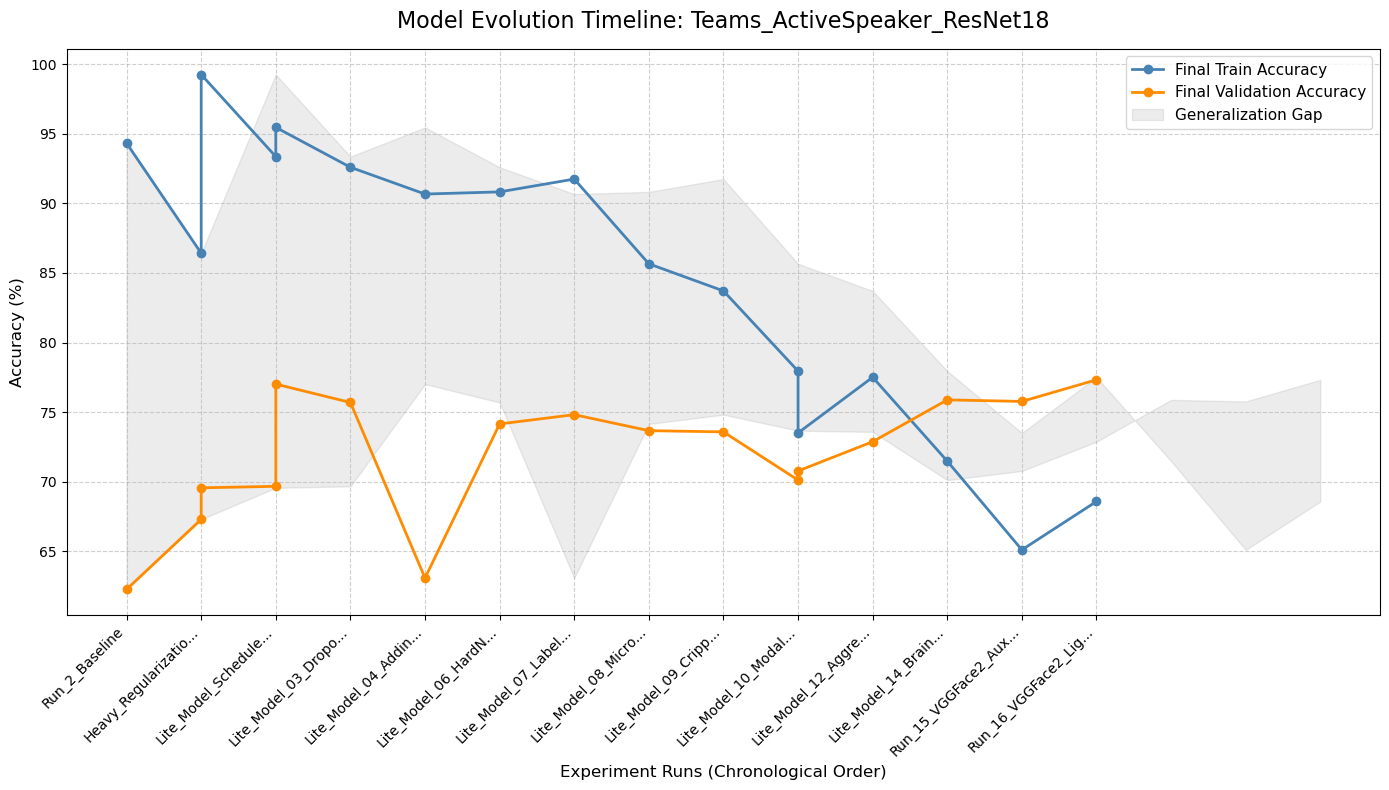

In [17]:
import mlflow
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

# Connect directly to the SQLite database
mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = MlflowClient()

experiment_name = "Teams_ActiveSpeaker_ResNet18"
experiment = client.get_experiment_by_name(experiment_name)

if not experiment:
    raise ValueError(f"Experiment '{experiment_name}' not found in mlflow.db")

# Fetch all runs, ordered chronologically
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["attributes.start_time ASC"]
)

run_names = []
train_accs = []
val_accs = []

for run in runs:
    name = run.data.tags.get("mlflow.runName", run.info.run_id[:8])
    
    # MLflow automatically stores the latest logged value in run.data.metrics
    t_acc = run.data.metrics.get("train_acc")
    v_acc = run.data.metrics.get("val_acc")
    
    # Only include runs that successfully logged both metrics
    if t_acc is not None and v_acc is not None:
        # Shorten excessively long run names for cleaner axis labels
        if len(name) > 22:
            name = name[:19] + "..."
            
        run_names.append(name)
        train_accs.append(t_acc)
        val_accs.append(v_acc)

# --- Plotting ---
plt.figure(figsize=(14, 8))

# Plot the progression lines
plt.plot(run_names, train_accs, marker='o', label='Final Train Accuracy', color='steelblue', linewidth=2)
plt.plot(run_names, val_accs, marker='o', label='Final Validation Accuracy', color='darkorange', linewidth=2)

# Shade the "Generalization Gap" between the two lines
plt.fill_between(range(len(run_names)), train_accs, val_accs, color='gray', alpha=0.15, label='Generalization Gap')

plt.title(f"Model Evolution Timeline: {experiment_name}", fontsize=16, pad=15)
plt.xlabel("Experiment Runs (Chronological Order)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)

# Format the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right', fontsize=10)

# Optimize grid and legend
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

As we can see the generalization gap does get smaller, but live testing the model had terrible performance as discussed. This shows that sometimes following just the numbers and trying to optimize them is not always the best option. The more ways we can check if we are on the right path the better. The live demo was crucial early adoption and I am really glad I actually decided to test it early on.

#### Version 2: Moving to [InceptionResnetV1](https://github.com/timesler/facenet-pytorch) trained on [VGGFace2](https://www.robots.ox.ac.uk/~vgg/publications/2018/Cao18/cao18.pdf) and implementing Auxilary Loss:

##### InceptionResnetV1
As I bridged the gap of the train and validation I saw it wasn't really working, so I had to change things up. I decided since the visual aspect wasn't really learning I can give it a better input.

Swapping to InceptionResnetV1 which is pre-trained on VGGFace2 - millions of faces, I was hoping it would describe the face features better, hence catching the mouth movement better.

Resnet has an efficient baseline for general image feature extraction, it isn't specialized in human faces.

Moving to the InceptionResnetV1 I had to change the preprocessing script. It was trained on 160x160 images so it is best if we use the same transformations:

In [18]:
resnet = InceptionResnetV1(pretrained='vggface2').eval().to('cuda')

v_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

This is why I mentioned that a lot of time was wasted on the preprocessing of the videos.

##### Auxilary Loss

In the [Light-ASD](https://arxiv.org/pdf/2303.04439) architecture, an auxiliary visual loss is used to force the visual encoder to learn lip-sync independently before fusing it with audio.

To implement this I made an independent classification head (`visual_aux`). This auxiliary head is tasked with predicting the active speaker label using only the visual embeddings, completely isolated from the audio pipeline. The loss computed from this visual-only prediction is the auxiliary loss, which is then added to the main cross-modal classification loss during backpropagation.

By forcing the visual encoder to independently solve the speaker detection task, the auxiliary loss should improve the network's ability to learns robust, discriminative facial features rather than passively riding on the audio network's gradients. Combined with audio modality dropout 
```
# Audio Modality dropout
        if self.training and torch.rand(1).item() < 0.5:
            a_feat = torch.zeros_like(a_feat)
        else:
            a_feat = self.audio_dropout(a_feat)
```
which 50% of the time zeroes out audio features during training - this should ensure that the model actively verifies visual lip synchronization instead of merely acting as a Voice Activity Detector (VAD).

###### Loss function

$$ L_{Final} = L_{AudioVisual} + \lambda * L_{Visual} $$

I went ahead and implemented it:

<img src="Images/resnet18-late-fusion-architecture.png" width=1000>

In [1]:
class ActiveSpeakerModel(nn.Module):
    def __init__(self, dropout_input=0.2, dropout_gru=0.1, dropout_audio=0.3, dropout_fusion=0.6, hidden_size=128):
        super(ActiveSpeakerModel, self).__init__()
        
        self.input_dropout = nn.Dropout(dropout_input)
        
        # VISUAL PATHWAY
        self.visual_gru = nn.GRU(
            input_size=512, # VGGFace2 outputs 512d, same as ResNet18
            hidden_size=hidden_size, 
            num_layers=1, 
            batch_first=True, 
            dropout=0 
        )
        
        self.gru_dropout = nn.Dropout(dropout_gru)
        
        # --- NEW: Light-ASD Visual Auxiliary Classifier ---
        self.visual_aux = nn.Linear(hidden_size, 2)
        
        # AUDIO PATHWAY
        self.audio_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.audio_dropout = nn.Dropout(dropout_audio)
        
        # FUSION LAYER
        self.fusion_$$ L_{Final} = L_{AudioVisual} + \lambda * L_{Visual} $$ = nn.Sequential(
            nn.Linear(hidden_size + 32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_fusion),
            nn.Linear(64, 2)
        )

    def forward(self, v, a):
        v = self.input_dropout(v)
        _, v_hidden = self.visual_gru(v)
        v_feat = self.gru_dropout(v_hidden[-1]) 
        
        a_feat = self.audio_conv(a).view(a.size(0), -1)

        # Audio Modality dropout
        if self.training and torch.rand(1).item() < 0.5:
            a_feat = torch.zeros_like(a_feat)
        else:
            a_feat = self.audio_dropout(a_feat)
            
        combined = torch.cat((v_feat, a_feat), dim=1)
        main_out = self.fusion_layer(combined)
        
        # --- NEW: Return both outputs during training for dual loss ---
        if self.training:
            v_out_aux = self.visual_aux(v_feat)
            return main_out, v_out_aux
            
        return main_out

SyntaxError: invalid syntax (3610155221.py, line 29)

In [5]:
def plot_run_accuracy(experiment_name, run_name, db_path="sqlite:///mlflow.db"):
    # Connect directly to the SQLite database
    mlflow.set_tracking_uri(db_path)
    client = MlflowClient()

    # 1. Fetch the Experiment
    experiment = client.get_experiment_by_name(experiment_name)
    if not experiment:
        print(f"Error: Experiment '{experiment_name}' not found in {db_path}")
        return

    # 2. Search for the specific run using its mlflow.runName tag
    query = f"tags.`mlflow.runName` = '{run_name}'"
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id], 
        filter_string=query
    )

    if not runs:
        print(f"Error: Run '{run_name}' not found in experiment '{experiment_name}'")
        return

    # Take the exact match
    target_run = runs[0]
    run_id = target_run.info.run_id
    
    print(f"Plotting Run: {run_name} (ID: {run_id})")

    try:
        # 3. Fetch the metric history for train and val accuracy
        train_acc_history = client.get_metric_history(run_id, "train_acc")
        val_acc_history = client.get_metric_history(run_id, "val_acc")
        
        # Extract the epoch steps and the recorded values
        train_epochs = [m.step for m in train_acc_history]
        train_values = [m.value for m in train_acc_history]
        
        val_epochs = [m.step for m in val_acc_history]
        val_values = [m.value for m in val_acc_history]

        if not train_epochs or not val_epochs:
            print("Error: Incomplete metric history found for this run.")
            return

        # 4. Plot the progression
        plt.figure(figsize=(12, 5))
        
        plt.plot(train_epochs, train_values, label="Train Accuracy", marker='o', color='steelblue', linewidth=2)
        plt.plot(val_epochs, val_values, label="Validation Accuracy", marker='o', color='darkorange', linewidth=2)
        
        plt.title(f"Accuracy Progression: {run_name}", fontsize=14, pad=15)
        plt.xlabel("Epoch", fontsize=12)
        plt.ylabel("Accuracy (%)", fontsize=12)
        
        plt.legend(loc="lower right", fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Ensure x-axis ticks align with epochs natively (integers)
        plt.xticks(train_epochs)
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error fetching metrics for {run_name}: {e}")

Plotting Run: Run_16_VGGFace2_LightReg (ID: 8dfb99b3d71e42239f8c5a3d904941cd)


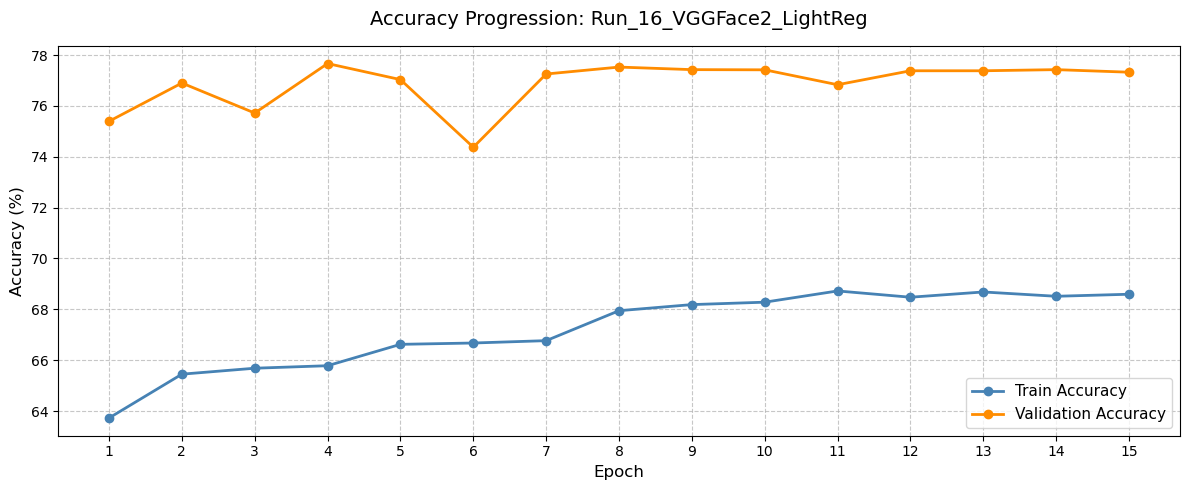

In [29]:
plot_run_accuracy("Teams_ActiveSpeaker_ResNet18", "Run_16_VGGFace2_LightReg")

Sadly the results weren't very different. The live demo was still not working correctly and picking up the microphone activation. 

##### The implementation mistake
Later I realized I had implmeneted the auxilary in a bad way. 

```
    def __init__(...)
        self.visual_aux = nn.Linear(hidden_size, 2)
    ...

    forward()
    ...
        _, v_hidden = self.visual_gru(v)
        v_feat = self.gru_dropout(v_hidden[-1])
    ...
        # --- NEW: Return both outputs during training for dual loss ---
        if self.training:
            v_out_aux = self.visual_aux(v_feat)
            return main_out, v_out_aux
```
Then in the `run_training()` function where I defined the loss function:

```
    criterion = nn.CrossEntropyLoss()
    loss_main = criterion(main_out, l)

    loss_v_aux = criterion(v_out_aux, l)
            
    loss = loss_main + (0.5 * loss_v_aux)
```

I was getting only the last hidden state of the visual GRU and passing it to the liner aux layer to produce 2 logits and classify it. Then compare it with the actual result with cross-entropy.

By passing that single summary vector to the `visual_aux` classifier, I was essentially asking the network:

> "Hey GRU, based on your memory of that entire 15-frame video clip, is this a speaking clip or a silent clip?"

The whole idea of the LightASD aux loss was to find the micro lip movements. I had to ask on each hidden state what it would classify it at that point. So 15 calssifications for 15 frames. 

What I needed to do was:
1. Extract the full `gru_out` tensor - which contains the hidden state for every single time step
    - `gru_out, v_hidden = self.visual_gru(v)`
2. Pass the entire sequence through the linear layer

    - `v_out_aux = self.visual_aux(gru_out)`
3. Finally then calculate the Cross-Entropy loss across all frames simultaneously.
    ```
    B, T, _ = v_out_aux.size()
    criterion = nn.CrossEntropyLoss()
    loss_main = criterion(main_out, l)

    # v_out_aux shape: (Batch, 15, 2)
    # l shape: (Batch,)
    B, T, _ = v_out_aux.size()
    
    # Flatten the auxiliary output: (Batch * 15, 2)
    v_out_aux_flat = v_out_aux.view(-1, 2)
    
    # Expand and flatten the labels to match every frame: (Batch * 15,)
    l_expanded = l.unsqueeze(1).expand(-1, T).reshape(-1)
    
    loss_v_aux = criterion(v_out_aux_flat, l_expanded)
            
    loss = loss_main + (0.5 * loss_v_aux)
    ```
   
We see a bit of undefitting here. Maybe I should have iterrated more on this, since it was a new pattern, but I wanted to try Early Fusion and get closer to the SOTA architectures so I pressed on 

##### Early-Fusion

I decided to try to implement the early-fusion tactic from the [Light-ASD](https://arxiv.org/pdf/2303.04439) paper:
My baseline model made sense, but it had a fatal flaw for lip-reading: it couldn't measure synchronization.

By the time the visual vector and the audio vector met at the fusion-head layer, the concept of "time" had already been erased. The network knew the person moved their head, and it knew there was a loud noise, but it was mathematically impossible for it to know if the mouth opened at the exact same fraction of a second the loud noise happened.

Here I ran into another problem. I had to reimplement the preprocessing script, again... 

- In a late fusion architecture, the goal is to extract a single "global" feature vector for the entire sequence. The preprocessing script took the entire audio waveform for the clip (e.g., ~0.5 seconds representing 15 frames) and converted it into one single, continuous mel-spectrogram.
    - Data Shape: The resulting tensor looks like `(1, 64, 16)` - representing one channel, 64 frequency bands, and the total time steps for the whole clip - `(8000 / 512) + 1 = 16` where 8000 is the total samples (16k Hz for 0.5 sec) and 512 is the default hop length of librosa.
- Early fusion requires strict, frame-by-frame synchronization. To concatenate audio and visual features before passing them to the GRU, the audio data must share the exact same temporal dimension as the video (15 frames).
    - Data Shape: This transforms the output from a single image into a temporal sequence of images, resulting in the `(15, 1, 64, 5)` shape - 15 distinct frames, each containing a 1-channel, 64-band spectrogram spanning just 5 audio time steps.

In this image you can see how the frame and it's audio spectrogram are combined before being fed to the GRU. This is early-fusion.

<img src="Images/early-fusion.png" width=600>

The implementation:

<img src="Images/early_fusion-architecture.png" width=1000>

In [ ]:
class TemporalActiveSpeakerModel(nn.Module):
    def __init__(self, dropout_input=0.1, dropout_gru=0.3, dropout_audio=0.2, dropout_classifier=0.3, hidden_size=128):
        super(TemporalActiveSpeakerModel, self).__init__()
        
        self.input_dropout = nn.Dropout(dropout_input)
        
        # AUDIO CNN (Processes the 15 micro-spectrograms individually)
        self.audio_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.audio_dropout = nn.Dropout(dropout_audio)
        
        # CROSS-MODAL GRU (Input is 512 Visual + 32 Audio = 544 dimensions per frame)
        self.cross_modal_gru = nn.GRU(
            input_size=544, 
            hidden_size=hidden_size,
            num_layers=1, 
            batch_first=True, 
            dropout=0 
        )
        
        self.gru_dropout = nn.Dropout(dropout_gru)
        
        # FINAL CLASSIFIER (No more late fusion, just evaluating the GRU's thought)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_classifier),
            nn.Linear(64, 2)
        )

    def forward(self, v, a):
        # v shape: (Batch, 15, 512)
        # a shape: (Batch, 15, 1, 64, 5)
        B, T, V_dim = v.size()
        _, _, C, H, W = a.size()
        
        v = self.input_dropout(v)
        
        # 1. Flatten Audio across Batch and Time dimensions to process through CNN
        a_flat = a.view(B * T, C, H, W)  # Shape: (Batch * 15, 1, 64, 5)
         #  a_feat = self.audio_conv(a_flat).view(B * T, -1) # Shape: (Batch * 15, 32)
        
        # Modality Dropout
        if self.training and torch.rand(1).item() < 0.5:
            a_feat = torch.zeros_like(a_feat)
        else:
            a_feat = self.audio_dropout(a_feat)
            
        # Reshape Audio back to sequence
        a_feat = a_feat.view(B, T, -1) # Shape: (Batch, 15, 32)
        
        # 2. FRAME-BY-FRAME FUSION
        combined = torch.cat((v, a_feat), dim=2) # Shape: (Batch, 15, 544)
        
        # 3. TEMPORAL MODELING
        _, gru_hidden = self.cross_modal_gru(combined)
        final_feat = self.gru_dropout(gru_hidden[-1]) # Shape: (Batch, 128)
        
        main_out = self.classifier(final_feat)
          
        return main_out

The audio is initially shaped `(Batch, 15, 1, 64, 5)`. By flattening the batch and time dimensions `(B * T)`, passing it through the CNN, and then reshaping it back to `(Batch, 15, 32)` I know the sequential order of the 15 audio features perfectly mirrors the 15 visual frames `(Batch, 15, 512)`.

What is important here is this line:
`combined = torch.cat((v, a_feat), dim=2)`

Because you are concatenating along `dim=2` (the feature dimension), PyTorch takes the visual vector for Frame 1 (512 dimensions) and attaches the audio vector for Frame 1 (32 dimensions) to the end of it, creating a single 544-dimensional vector. This happens simultaneously for all 15 frames.

Finally, the `cross_modal_gru` receives a sequence of `(Batch, 15, 544)`. Instead of trying to figure out how a finished visual thought relates to a finished audio thought (late fusion), the GRU steps through time analyzing the combined audio-visual state at every single fraction of a second.

Plotting Run: Run_18_CrossModal_Temporal (ID: 0e177fde87174664b428e61ff78d7406)


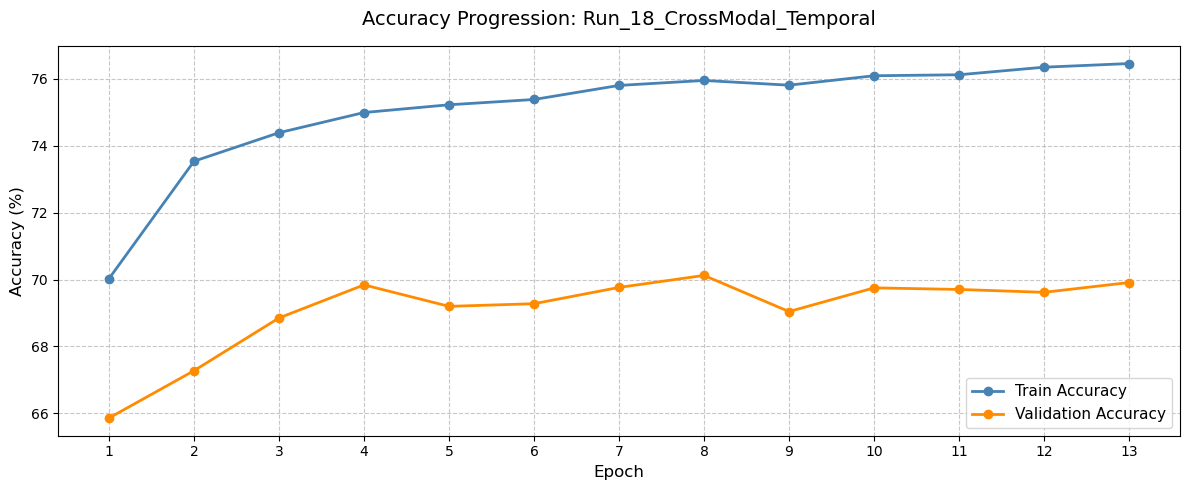

In [30]:
plot_run_accuracy("Teams_ActiveSpeaker_Temporal", "Run_18_CrossModal_Temporal")

The result was still the same in the live demo - mic detector. This time we see overfitting again tho.

#### Version 3: Cross-Attention (Current SOTA)

I decided to look at what the big dogs were doing, since what I am obviously doesn't work. I found this [SOTA ranking](https://hyper.ai/en/sota/tasks/audio-visual-active-speaker-detection/benchmark/audio-visual-active-speaker-detection-on-ava-activespeaker) and saw that the SOTA currently is [LoCoNet + TalkNCE](https://arxiv.org/pdf/2309.12306)

This is the final solution and it implements cross-attention to force modality alignment and uses early fusion of the audio and frame inputs before the GRU

##### Cross-Attention
To force the network to actively verify synchronization, a Multihead Cross-Attention layer is utilized. The visual features act as the Query, while the audio features act as the Key and Value pairs. This mechanism allows the model to actively search the audio stream for signals that match the visual lip movements.

##### Switching GRU output propagation
I noticed the way I was propagating the GRU output to the classifier wasn't ideal perhaps. I was just getting the last hidden state. Essentially with a small hidden state vector of 128 it was hard for the visual information to reach the end of the GRU. I thought this was the reason why it was performing bad. So I switched to getting the mean of all hidden states of the GRU and removed the dropout after it. 

Another thing I added (that my lecturer suggested) is contrastive learning. I replaced the visual aux with it.

##### Contrastive Learning
Contrastive learning is a self-supervised technique that teaches a model to understand relationships between different data types by organizing them in a shared geometric space. In the context of active speaker detection, it acts as a critical regularizer to prevent the network from taking the "mic-picker" shortcut, where it simply triggers on loud audio. By applying a Cosine Embedding Loss to the intermediate visual and audio projections, the network is mathematically forced to pull synchronized, positive pairs (moving lips and their corresponding voice) closer together, while actively pushing apart mismatched, hard negative pairs (silent faces or shifted audio). 

This explicit alignment ensures that the model genuinely learns the temporal dynamics of lip-sync and cross-modal correlation before passing the extracted features to the final classifier.

```
    contrastive_target = torch.where(label == 1, torch.tensor(1.0).to(DEVICE), torch.tensor(-1.0).to(DEVICE))
    loss_contrast = contrastive_criterion(v_embed, a_embed, contrastive_target)
```

##### The loss function

$$ L_{Final} = L_{AudioVisual} + \lambda * L_{contrast} $$

`loss = loss_main + (AUX_WEIGHT * loss_v_aux) + (CONTRASTIVE_WEIGHT * loss_contrast)`

The cross-modal features are passed into a final GRU layer. This ensures the model captures the full temporal context of the 15-frame sequence before routing the final hidden state to the classifier.

<img src="Images/cross-attension-architecture.png" width=1000>

In [ ]:
class CrossAttentionActiveSpeakerModel(nn.Module):
    def __init__(self, dropout_audio=0.2, hidden_size=128):
        super(CrossAttentionActiveSpeakerModel, self).__init__()
        
        self.audio_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.audio_dropout = nn.Dropout(dropout_audio)
        
        self.visual_aux = nn.Linear(512, 2)
        self.visual_proj = nn.Linear(512, hidden_size)
        self.audio_proj = nn.Linear(32, hidden_size)
        
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=4, batch_first=True)
        
        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size, 
            num_layers=1, 
            batch_first=True
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, v, a):
        B, T, V_dim = v.size()
        _, _, C, H, W = a.size()
        
        a_flat = a.view(B * T, C, H, W) 
        a_feat = self.audio_conv(a_flat).view(B * T, -1) 
        
        if self.training and torch.rand(1).item() < 0.5:
            a_feat = torch.zeros_like(a_feat)
        else:
            a_feat = self.audio_dropout(a_feat)
            
        a_feat = a_feat.view(B, T, -1) 
        
        v_proj = self.visual_proj(v) # Shape: (B, 15, 128)
        a_proj = self.audio_proj(a_feat) # Shape: (B, 15, 128)
        
        attn_out, _ = self.cross_attn(query=v_proj, key=a_proj, value=a_proj)
        gru_out, _ = self.gru(attn_out)
        final_feat = gru_out.mean(dim=1) 
        
        main_out = self.classifier(final_feat)
        
        if self.training:
            v_out_aux = self.visual_aux(v.mean(dim=1))
            # Return the mean of the projections to apply Contrastive Loss
            return main_out, v_out_aux, v_proj.mean(dim=1), a_proj.mean(dim=1)
            
        return main_out

2026/02/25 22:32:10 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/25 22:32:10 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/25 22:32:10 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/25 22:32:10 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/25 22:32:10 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/25 22:32:10 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/25 22:32:10 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/25 22:32:10 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Plotting Run: Run_28B_Contrastive_NoAux_Final (ID: 88d6e78ba7ac46b8b91456b354990b58)


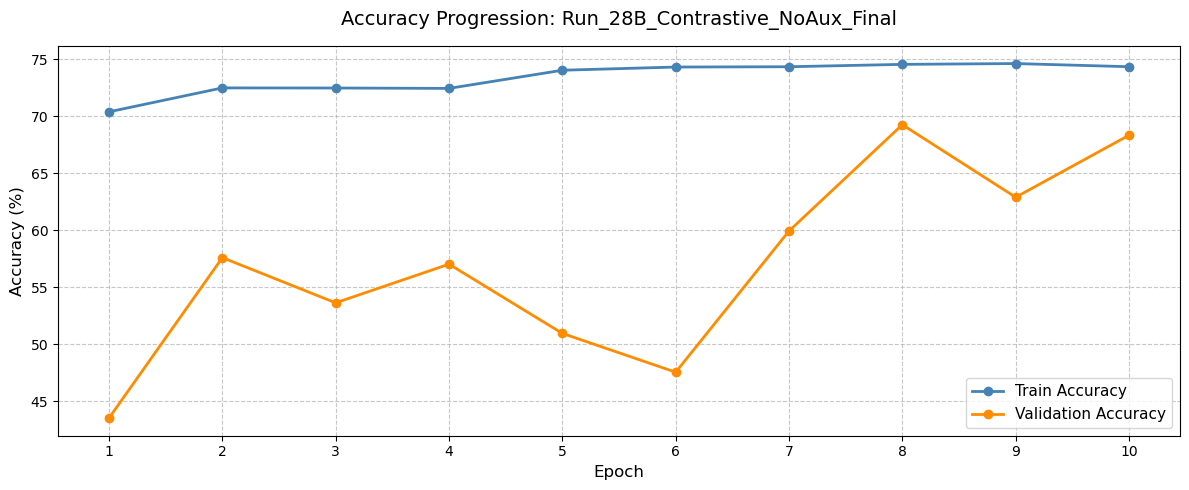

In [6]:
plot_run_accuracy("Teams_ActiveSpeaker_Temporal", "Run_28B_Contrastive_NoAux_Final")

Sadly the result was still the same. Microphone detector. 

At this point I was 2 days out of the final deadline and was panicing like crazy why everything I tried didnt work. Stress levels were high.

One thing that my lecturer noted is that the learning curve step was looking pretty bad.

#### Training Variance and Hard Negative Mining
During training, the train_loss_step metric I tracked exhibited high variance (jitter). This is not a sign of gradient instability, but rather an intentional architectural feature.

To prevent the network from defaulting to an audio-volume shortcut (the "mic-picker" problem) 2 things were implemented that influenced that metric:
- **Hard Negative Mining**: The data loader dynamically injects hard negative samples into 20%/5% of the batches by artificially shifting the audio sequence out of sync while forcing the label to 0 (Silence). 
- **Severe Modality Dropout**: The zeroing out of the whole audio input 50% of the time (aggressive I know, I was desperate)

Consequently, when the network encounters these sabotaged batches, the Cross-Entropy and Contrastive loss naturally spike as the model is heavily penalized for relying solely on audio amplitude. This forces the Cross-Attention layer to strictly evaluate visual lip-sync.

Model convergence is therefore proven not by step-loss smoothness, but by the consistent downward trajectory of the epoch-level training and validation loss.

To visualize and prove this I did an A/B test with and without these modifications:

In [12]:
def smooth_curve(points, factor=0.9):
    """Calculates the Exponential Moving Average (EMA) for noisy step metrics."""
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

def plot_ab_testing_metric(experiment_name, run_names, metric_name, db_path="sqlite:///mlflow.db", smoothing=0.9):
    # Connect directly to the SQLite database
    mlflow.set_tracking_uri(db_path)
    client = MlflowClient()

    # 1. Fetch the Experiment
    experiment = client.get_experiment_by_name(experiment_name)
    if not experiment:
        print(f"Error: Experiment '{experiment_name}' not found in {db_path}")
        return

    plt.figure(figsize=(12, 5))
    
    # Pre-defined professional colors for A/B testing
    colors = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

    # 2. Loop through the runs you want to compare
    for idx, run_name in enumerate(run_names):
        # Search for the specific run using its mlflow.runName tag
        query = f"tags.`mlflow.runName` = '{run_name}'"
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id], 
            filter_string=query
        )

        if not runs:
            print(f"Error: Run '{run_name}' not found in experiment '{experiment_name}'")
            continue

        target_run = runs[0]
        run_id = target_run.info.run_id
        color = colors[idx % len(colors)]

        try:
            # 3. Fetch the metric history
            metric_history = client.get_metric_history(run_id, metric_name)
            steps = [m.step for m in metric_history]
            values = [m.value for m in metric_history]

            if not steps:
                print(f"Warning: No data found for metric '{metric_name}' in run '{run_name}'.")
                continue

            # 4. Plot the progression
            if smoothing > 0:
                # Plot faint raw data
                plt.plot(steps, values, color=color, alpha=0.3)
                # Plot bold smoothed data
                smoothed_values = smooth_curve(values, factor=smoothing)
                plt.plot(steps, smoothed_values, label=f"{run_name}", color=color, linewidth=2)
            else:
                # Plot standard line if smoothing is 0
                plt.plot(steps, values, label=run_name, color=color, linewidth=2)

        except Exception as e:
            print(f"Error fetching metrics for {run_name}: {e}")

    # Styling perfectly matched to your previous function
    plt.title(f"A/B Testing: {metric_name}", fontsize=14, pad=15)
    plt.xlabel("Training Step (Batch)", fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    
    plt.legend(loc="upper right", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

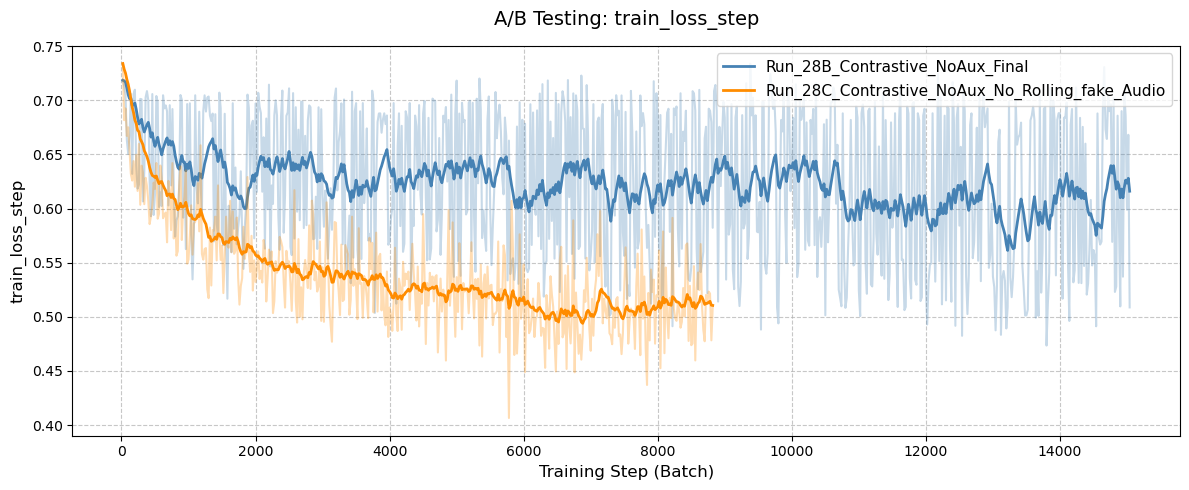

In [13]:
run_a = "Run_28B_Contrastive_NoAux_Final"  
run_b = "Run_28C_Contrastive_NoAux_No_Rolling_fake_Audio"

# Execute the plot
plot_ab_testing_metric(
    experiment_name="Teams_ActiveSpeaker_Temporal",
    run_names=[run_a, run_b], 
    metric_name="train_loss_step",
    smoothing=0.9 # Set to 0 if you just want the raw jagged lines
)

The `train_loss_step` is logged every 50 batches of every epoch. This allows us to see what is happening during the epoch.

Experiment A: **Run_28B_Contrastive_NoAux_Final** 

This is with all the guardrails put on. We can see the amplitude of the learning curve is huge. It is going up and down every 50 batches like crazy. This is happening because it is trying to learn the visual aspects more heavily but it was futile (more about this big revelation later). It was trying to learn the audio signal but I was punishing it so much and was going crazy.

The smoothed out line shows that the model is learning, but very erraticly and slowly.

Experiment B: **Run_28C_Contrastive_NoAux_No_Rolling_fake_Audio**

This is the try with the same architecture but without the guardrails. I removed the biggest audio punishments and we can see the amplitude is a lot better and it is learning quite faster (the general smoothed trend is going down faster) 

This is because it is much easier to learn on the audio at this point.

## Section 6: The big revelation: Garbage in - garbage out

So I thought rationally. If everything I do to the architecture doesn't work, then it is the data's fault.

Everything I was doing was giving clear results of working in terms of learning process and results, but on a live demo it was just a microphone picker. 

### 6.1 My hyphotesis of why it is was not working:

- **The Static Face Trap**: InceptionResnetV1 (trained on VGGFace) outputs a 512D vector that describes the static geometry of a face. Over 15 frames, those 512 numbers barely change because the person's identity doesn't change. The GRU was desperately looking for motion, but it was just being fed the exact same Brad Pitt face vector 15 times in a row.

- **The Audio Shortcut**: Meanwhile, the Mel-spectrograms have massive, obvious differences between "silence" and "speech" (amplitude/volume).

- **The Exploit**: The network realized: "Why should I do the incredibly difficult mathematical gymnastics of trying to find micro-movements in static VGGFace vectors, when I can just look at the audio vector, see if it's loud, and guess '1'?"

So I decided to actually test the input vectors. They are vectors, so simple to compare:

--- Analysis Report ---
File: Processed_Video_Sample/9Y_l9NsnYE0#9Y_l9NsnYE0@0900_0960_1#900.20.pt
Label: Speaking (1)
Avg Consecutive Frame Similarity: 0.9984
Mean Variance Across 512 Features: 0.000014
-----------------------


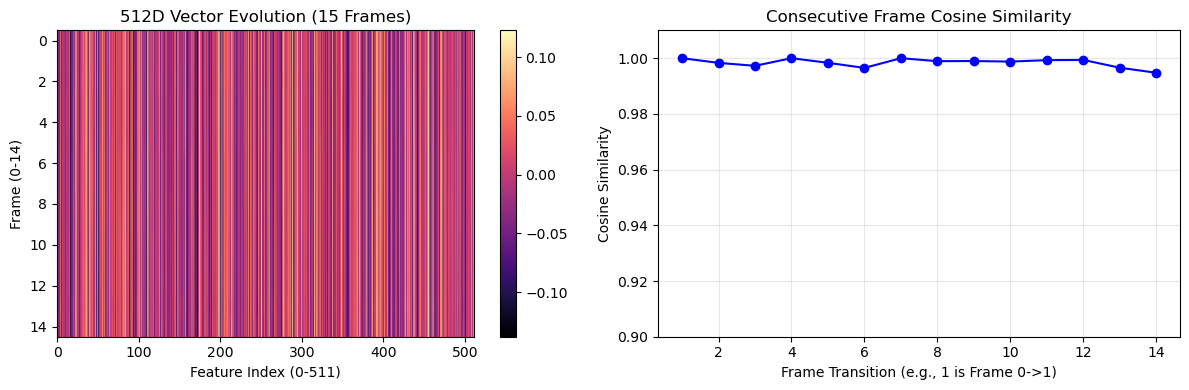

In [17]:
def analyze_vggface_variance(pt_file_path):
    # Load the tensor data
    data = torch.load(pt_file_path, weights_only=True)
    v = data['visual']  # Shape should be [15, 512]
    
    if v.shape != (15, 512):
        print(f"Unexpected shape: {v.shape}. Expected (15, 512).")
        return

    # 1. Cosine Similarity (How identical is Frame N to Frame N+1?)
    # 1.0 means perfectly identical. 0.0 means completely orthogonal.
    cos_sims = cosine_similarity(v[:-1], v[1:], dim=1).numpy()
    
    # 2. Feature Variance (How much does each of the 512 numbers change across 15 frames?)
    variances = torch.var(v, dim=0).numpy()
    mean_var = np.mean(variances)
    
    print(f"--- Analysis Report ---")
    print(f"File: {pt_file_path}")
    print(f"Label: {'Speaking (1)' if data['label'] == 1 else 'Silent (0)'}")
    print(f"Avg Consecutive Frame Similarity: {np.mean(cos_sims):.4f}")
    print(f"Mean Variance Across 512 Features: {mean_var:.6f}")
    print(f"-----------------------")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot A: Heatmap of the features
    # If the vector is static, this will look like solid vertical stripes.
    cax = axes[0].imshow(v.numpy(), aspect='auto', cmap='magma')
    axes[0].set_title("512D Vector Evolution (15 Frames)")
    axes[0].set_xlabel("Feature Index (0-511)")
    axes[0].set_ylabel("Frame (0-14)")
    fig.colorbar(cax, ax=axes[0])
    
    # Plot B: Frame-to-Frame Similarity
    axes[1].plot(range(1, 15), cos_sims, marker='o', linestyle='-', color='b')
    axes[1].set_title("Consecutive Frame Cosine Similarity")
    axes[1].set_xlabel("Frame Transition (e.g., 1 is Frame 0->1)")
    axes[1].set_ylabel("Cosine Similarity")
    axes[1].set_ylim(0.9, 1.01) # Zoomed in to show micro-changes
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

TEST_FILE = "Processed_Video_Sample/9Y_l9NsnYE0#9Y_l9NsnYE0@0900_0960_1#900.20.pt" 
analyze_vggface_variance(TEST_FILE)

Yup, that is the same visualization (on the right) of the visual embedding from earlier.

What is on the right is the Cosine Similarities. It compares how similar the consecutive frames are. 1 with 2, 2 with 3 etc.

This means that to the neural network, the video looks like a completely still photograph.

**There was no useful visual information in the first place**

I was fighting an uphill losing battle. No matter how much I punished the model for learning the audio path it had no other alternative. I was feeding it basically the same 15 images for every sample. The InceptionResnetV1 backbone model indeed was trained on faces, but that doesn't mean it understands lip movement. It can understand nose, eyes, jaw line etc, but when the lips move it doesn't really care, hence the results I was getting.

#### Mean Variance across the 512 features
We can see that metric is 0.000014, but what does that mean?

Instead of comparing whole frames, `torch.var(v, dim=0)` looks at just a single feature out of the 512 (let's say, Feature #42) and tracks how much that specific number fluctuates up and down across the 15 time steps. It does this for all 512 features and averages them (`mean_var = np.mean(variances)`).

If a person's mouth is opening and closing rapidly, the numbers representing the lips should be spiking up and down wildly over the 15 frames, resulting in high variance.

A variance of 0.000014 is a mathematical flatline. It means that across the entire 0.5-second clip, none of the 512 features are changing. The numbers are entirely static.

Lets look at a whole video sample, not just 1. 

I am using the `9Y_l9NsnYE0` VideoId left as an example if you want to run the Download -> Preprocess pipeline so you can execute this bit as well. ( I can't commit the dataset obviously)

Found 7993 files. Starting analysis...


Processing Tensors: 100%|██████████████████████████████████████████████████████████| 7993/7993 [00:40<00:00, 197.79it/s]



DATASET ANALYSIS REPORT
Class: Speaking (1) (Count: 1920)
  -> Avg Frame-to-Frame Similarity: 0.980038
  -> Avg Feature Variance:          0.000126
----------------------------------------
Class: Silent (0) (Count: 6073)
  -> Avg Frame-to-Frame Similarity: 0.973938
  -> Avg Feature Variance:          0.000152
----------------------------------------


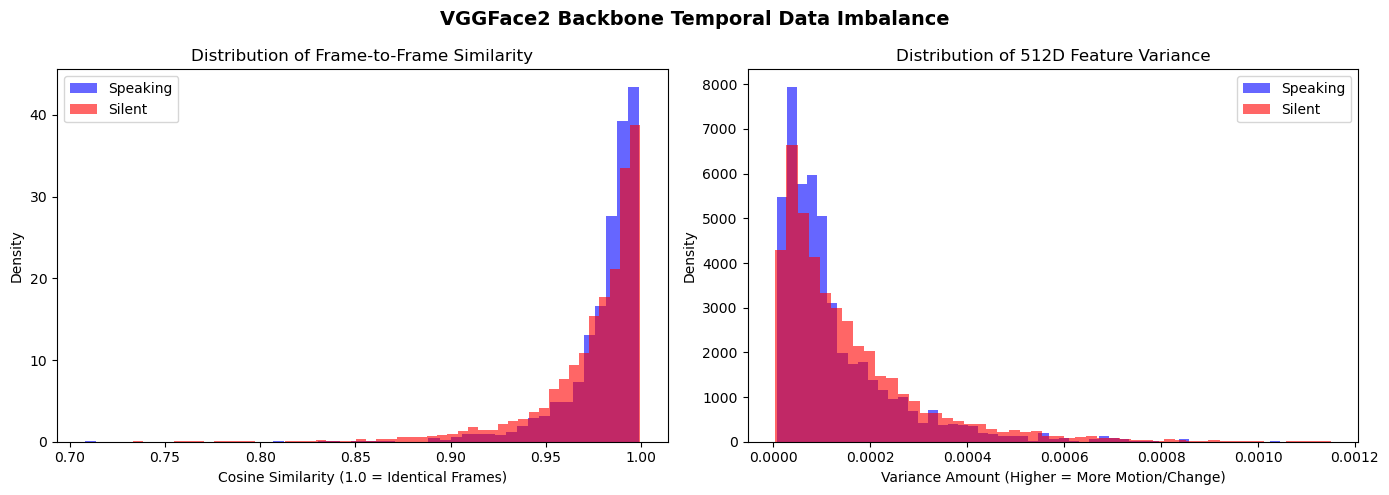

In [21]:
def analyze_dataset_variance(folder_path, max_files=None):
    # Find all .pt files in the directory
    pt_files = glob.glob(os.path.join(folder_path, "*.pt"))
    if max_files:
        pt_files = pt_files[:max_files]
        
    print(f"Found {len(pt_files)} files. Starting analysis...")

    # Dictionaries to hold our metrics for each class
    metrics = {
        1: {'sims': [], 'vars': [], 'name': 'Speaking (1)'},
        0: {'sims': [], 'vars': [], 'name': 'Silent (0)'}
    }

    for pt_file in tqdm(pt_files, desc="Processing Tensors"):
        try:
            # Load data to CPU
            data = torch.load(pt_file, weights_only=True, map_location='cpu')
            v = data['visual']  # Shape: [15, 512]
            label = int(data['label'])
            
            # 1. Average Cosine Similarity across consecutive frames for this file
            file_sims = cosine_similarity(v[:-1], v[1:], dim=1)
            avg_sim = file_sims.mean().item()
            
            # 2. Mean Variance across the 512 features for this file
            file_vars = torch.var(v, dim=0)
            avg_var = file_vars.mean().item()
            
            # Store results
            metrics[label]['sims'].append(avg_sim)
            metrics[label]['vars'].append(avg_var)
            
        except Exception as e:
            pass # Skip corrupted files silently

    # --- Summary Printout ---
    print("\n" + "="*40)
    print("DATASET ANALYSIS REPORT")
    print("="*40)
    
    for lbl in [1, 0]:
        data_sims = metrics[lbl]['sims']
        data_vars = metrics[lbl]['vars']
        count = len(data_sims)
        
        if count == 0:
            continue
            
        print(f"Class: {metrics[lbl]['name']} (Count: {count})")
        print(f"  -> Avg Frame-to-Frame Similarity: {np.mean(data_sims):.6f}")
        print(f"  -> Avg Feature Variance:          {np.mean(data_vars):.6f}")
        print("-" * 40)

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Cosine Similarity Distribution
    axes[0].hist(metrics[1]['sims'], bins=50, alpha=0.6, label='Speaking', color='blue', density=True)
    axes[0].hist(metrics[0]['sims'], bins=50, alpha=0.6, label='Silent', color='red', density=True)
    axes[0].set_title("Distribution of Frame-to-Frame Similarity")
    axes[0].set_xlabel("Cosine Similarity (1.0 = Identical Frames)")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    
    # Plot 2: Feature Variance Distribution
    axes[1].hist(metrics[1]['vars'], bins=50, alpha=0.6, label='Speaking', color='blue', density=True)
    axes[1].hist(metrics[0]['vars'], bins=50, alpha=0.6, label='Silent', color='red', density=True)
    axes[1].set_title("Distribution of 512D Feature Variance")
    axes[1].set_xlabel("Variance Amount (Higher = More Motion/Change)")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    plt.suptitle("VGGFace2 Backbone Temporal Data Imbalance", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Point this to a folder with a good mix of your training .pt files
DATASET_FOLDER = "Processed_Video_Sample" 
    
# You can set max_files=5000 if you just want a quick sample instead of the whole dataset
analyze_dataset_variance(DATASET_FOLDER, max_files=None)

When we split the data into classes and take a closer look:

**We can see that the Speaking class (1) actually has lower differences between frames than the Silent class (0)**

Visually we can see that the blue (speaking) is towering over the red (silent) which means there are more occurences of it than the latter. 

This is even worse than the single example. 

**This proves that in the eyes of the VGGFace2 backbone, a person shouting looks mathematically identical to a person sitting in complete silence.**

### 6.2 Live-demo

A very crude Gemini 3.1 Pro generated `live_demo_attension.py` file is attached to the project with which you can test the last best model (microphone detection only really ...)

I didn't have time to explore how it works or what exactly it is doing. I needed a quick way to live test the resulting model.
> I am aware that this problem is mic/video sync sensitive, so I used a version of it on a raw video sample to generate the bounding boxes of active speaker detection on top of the raw video, and it was the same result as the live_demo. The idea was to isolate any possible desync of the live_demo but as we saw in the end it didn't really matter. The backbone was the issue

1. Activate the virtual env `active_speaker` under windows
2. Execute in the cmd `python live_demo_attension.py` in the root project directory

It takes a couple of seconds to buffer the person's face and then it starts predicting. In the video test mentioned above it was taking much less time, so I presume the recognition and preprocessing pipeline was slow, thus taking longer than 15 frames to buffer the face for a prediction

## Section 7: Conclusion

> *No final test for the AVA-test set, since no working model was produced

It is very important to thouroughly check your data before starting the Experimentation Phase

### 7.1 Was the project goal achieved?
Initially I set out to create a zoom-in feature on the active speaker on a camera feed.

**Positives**:
1. I managed to document the journey sucessfully
2. Created an efficient offline dataset
3. I followed good Machine Learning practices
    - A good train/val/test split
    - Regularization and model capacity reduction upon seeing over-fitting
    - Battling audio dominance through the many techniques discusses so far
    - Iterating logically the networks architecture, by adding possible modern SOTA solutions
    - Found the root cause why it wasn't working in the end

**Negatives**:
1. I failed to create a working Active Speaker Detection DNN due to a bad backbone choice
2. I failed to create an application of zooming-in to the active speaker due to the lack of a working ASD DNN

### 7.2 What I have learned

- Check the input data in multiple ways and make sure it is what you expect it to be
- Do more research in the early phase to avoid the VGGFace2 issue (The downside of top-down approach and rushing to make it happen)
- Got practical experience of working with visual and audio data
- Techniques like:
    -  Frozen Pre-trained Visual Backbone - Using InceptionResnetV1 to extract 512-dimensional semantic embeddings instead of training on raw video pixels prevents spatial overfitting on the visual data.
    -  Dynamic Hard Negative Mining - Artificially shifting the audio sequence out of sync in a percentage of the batches and forcing the ground-truth label to Silence(0) heavily penalizes the network for taking an "audio-volume shortcut."
    -  Severe Modality Dropout: Zeroing out the entire audio input tensor certain percentage of the time during training penalizes the network for taking an "audio-volume shortcut."
    -  Cross-Attention Early Fusion: Replacing raw concatenation with an attention mechanism forces the network to mathematically evaluate the correlation between audio and visual features before temporal modeling.
    -  Contrastive Loss: Mathematically bending and aligning the static visual feature space with the highly dynamic audio space.
      
### 7.3 What could be done better

- **Temporally-Aware Visual Backbone**: Variance analysis proved VGGFace2 aggressively filters out lip movement to preserve static identity. Replacing it with a backbone pre-trained/fine-tuned on lip-reading tasks would provide significantly richer temporal features.
- **Dataset Cleaning (Dubbed Audio)**: The dataset contains dubbed movies where lip movements naturally do not match the spoken words. Removing those samples should reduce label noise.
- **Better offline dataset naming**: Adding the label in the file name of the .pt files for easier work with them later
- **Better preprocessing speeds**: Add multithreading to the preprocessing script

## Section 8: Bibliography

1. Chung, J. S., et al. (2019). "AVA-ActiveSpeaker: An Audio-Visual Dataset for Active Speaker Detection." *arXiv preprint arXiv:1901.01342*. Available at: https://arxiv.org/abs/1901.01342
2. Google Research. (n.d.). *AVA Dataset*. Available at: https://research.google.com/ava/
3. CVD Foundation. (n.d.). *AVA-Dataset S3 Mirror*. GitHub. Available at: https://github.com/cvdfoundation/ava-dataset
4. Cao, Q., Shen, L., Xie, W., Parkhi, O. M., & Zisserman, A. (2018). "VGGFace2: A dataset for recognising faces across pose and age." *2018 13th IEEE International Conference on Automatic Face & Gesture Recognition (FG 2018)*, pp. 67-74. Available at: https://arxiv.org/pdf/1710.08092
5. Schroff, F., Kalenichenko, D., & Philbin, J. (2015). "FaceNet: A unified embedding for face recognition and clustering." *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, pp. 815-823.
6. Liao, J., Duan, H., Feng, K., Zhao, W., Yang, Y., & Chen, L. (2023). "A Light Weight Model for Active Speaker Detection." *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*. Available at: https://arxiv.org/abs/2303.04439
7. Hyper.AI. (n.d.). *Audio-Visual Active Speaker Detection on AVA-ActiveSpeaker Leaderboard*. Available at: https://hyper.ai/en/sota/tasks/audio-visual-active-speaker-detection/benchmark/audio-visual-active-speaker-detection-on-ava-activespeaker
8. Jung, C., Lee, S., Nam, K., Rho, K., Kim, Y. J., Jang, Y., & Chung, J. S. (2023). "TalkNCE: Improving Active Speaker Detection with Talk-Aware Contrastive Learning." *arXiv preprint arXiv:2309.12306*. Available at: https://arxiv.org/pdf/2309.12306
9. FastPix. (2024). "Understanding Video Inter-frame Compression: I-frames, P-frames, and B-frames." *FastPix Blog*. Available at: https://www.fastpix.io/blog/understanding-video-inter-frame-compression
10. Google. (2024). "Gemini: A Large Language Model." *Google AI Research*. Available at: https://deepmind.google/technologies/gemini/